In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from flax import nnx


from probjax.nn.loss_fn.denoising import build_time_dependent_denoising_loss

from probjax.nn import MLP, GaussianFourierEmbedding
from probjax.nn.nets.diffusion_model import EDM, VE, VP


In [5]:
def generate_data(key):
    # Mixture of Gaussians
    key, subkey = jax.random.split(key)
    theta = jax.random.normal(subkey, ())
    u = jax.random.uniform(subkey)
    eps = jax.random.normal(subkey, (2,))
    x = jnp.where(u < 0.5, eps[0]-theta, eps[1]+theta)
    return theta[None],x[None]

[1.167]


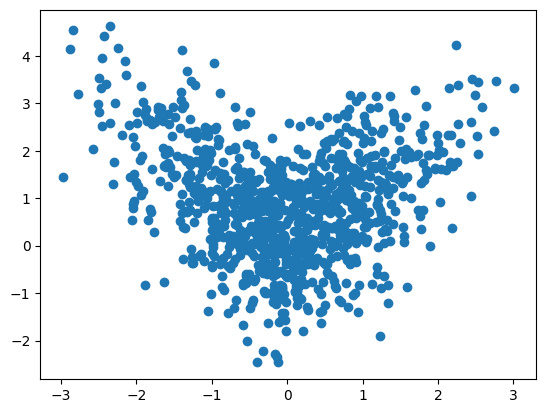

In [7]:
thetas, xs = jax.vmap(generate_data)(jax.random.split(jax.random.PRNGKey(0), 1000))
print(xs.std(0))
plt.scatter(thetas, xs)

In [11]:
d = 1
class BaseModel(nnx.Module, experimental_pytree=True):
    def __init__(self, d,d_context, rngs) -> None:
        self.time_embedding = GaussianFourierEmbedding(1,4, rngs=rngs)
        #self.time_embedding = lambda t: jnp.repeat(t, 5, axis=-1)
        self.mlp = MLP([d+4 + d_context,50,50,50,d], rngs=rngs)

    def __call__(self, t,x, context, *args, **kwargs):
        time_embed = self.time_embedding(t)
        inp = jnp.concatenate([time_embed, x, context], axis=-1)
        output = self.mlp(inp)
        return output

net = BaseModel(1, 1,nnx.Rngs(0))
model = EDM(net, std0=1.)
params = nnx.state(model, nnx.Param)

In [13]:
nnx.display(model)

In [14]:
def mean_fn(t, x):
    return x

def std_fn(t, x):
    return model.std_fn(t) 

denoiser_loss_fn = build_time_dependent_denoising_loss(model, mean_fn=mean_fn, std_fn=std_fn, weight_fn=model.weight_fn)

In [15]:
std_fn(0.00001,0)

Array([0.], dtype=float32, weak_type=True)

In [18]:
def loss_fn(params, x, rng):
    theta, x = x
    rng_times, rng_loss = jax.random.split(rng, 2)
    nnx.update(model, params)
    logt = jax.random.normal(rng_times, shape=(x.shape[0], 1)) * 1.2 - 1.2
    # t = jnp.exp(logt) + 0.0001
    
    # Beta proposal sampling more from the beginning
    t = jax.nn.sigmoid(logt)


    loss = denoiser_loss_fn(params, t, theta, context=x, rng=rng_loss)
    return jnp.mean(loss)


In [21]:
loss_fn(params, (thetas,xs), jax.random.PRNGKey(0))

Array(1.056, dtype=float32)

In [22]:

import optax

opt = optax.chain(optax.adaptive_grad_clip(1.), optax.adam(1e-3))
opt_state = opt.init(params)
@jax.jit
def update(params, opt_state, x, rng):
    loss, grads = jax.value_and_grad(loss_fn)(params, x, rng)
    updates, opt_state = opt.update(grads, opt_state, params=params)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss

In [23]:
key = jax.random.key(0)

In [24]:
model.std_fn(1.)

Array([1.], dtype=float32, weak_type=True)

In [25]:
losses = []
for i in range(2000):
    l = 0.
    for j in range(10):
        key,key_data, key_loss = jax.random.split(key, 3)
        xs = jax.vmap(generate_data)(jax.random.split(key_data, 1000))
        params, opt_state, loss = update(params, opt_state, xs,key_loss)
        l += loss
    losses.append(l/10)

KeyboardInterrupt: 

In [26]:
nnx.update(model, params)

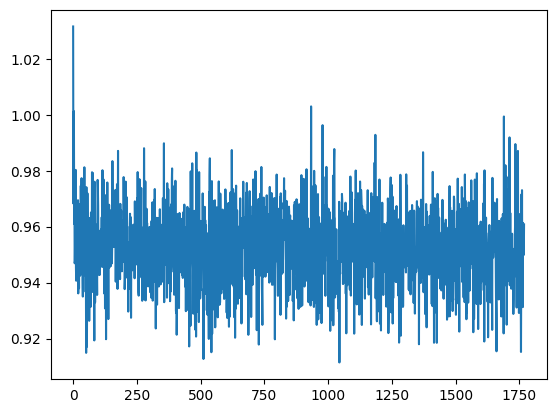

In [27]:
plt.plot(losses)

In [28]:
from probjax.utils.odeint import odeint

def sample(rng, context,T_end=1.):
    rng_init, rng_sample = jax.random.split(rng)
    eps = jax.random.normal(rng_init, (d,)) 
    ts = jnp.linspace(0.01, T_end, 200)

    def drift(t, x):
        t = jnp.atleast_1d(t)
        f = model.drift(t,x)
        g = model.diffusion(t, x)
        score = model.score(t,x, context=context)
        return (f -0.5*g**2*score).reshape(x.shape)

    return odeint(drift, eps,ts[::-1], method="heun")


In [29]:
std_fn(0.001,0)

Array([0.001], dtype=float32, weak_type=True)

In [47]:
model.score(jnp.array([1.]), jnp.array([5.]), context=jnp.array([4.]))

Array([-1.995], dtype=float32)

In [48]:
keys = jax.random.split(key,  (10_000,))

In [55]:
xs = jax.vmap(lambda k: sample(k, context=jnp.array([6.])))(keys)

(-6.0, 6.0)

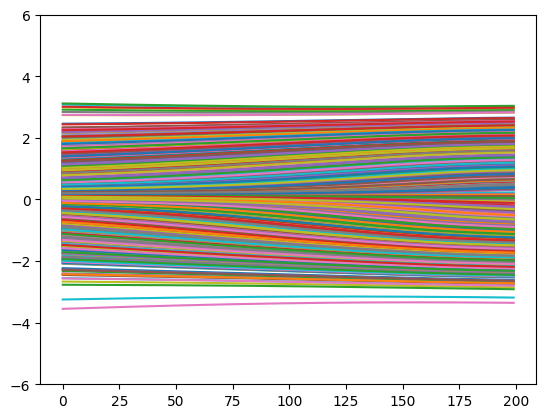

In [56]:
_ = plt.plot(xs[::10,:,0].T)
plt.ylim(-6,6)

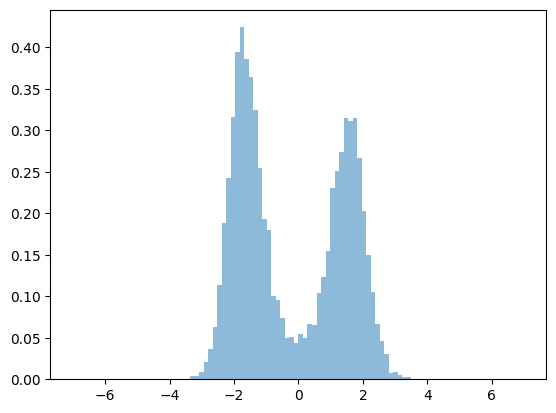

In [57]:
_ = plt.hist(xs[:,-1].flatten(), bins=100, density=True, range=(-7,7), alpha=0.5)

In [ ]:
from probjax.utils.sdeint import sdeint

def sample(rng, T_end=1.):
    rng_init, rng_sample = jax.random.split(rng)
    eps = jax.random.normal(rng_init, (d,)) * (model.std_fn(T_end) + model.std0)
    ts = jnp.linspace(0.01, T_end, 500)

    def drift(t, x):
        t = jnp.atleast_1d(t)
        f = model.drift(t,x)
        g = model.diffusion(t,x)
        score = model.score(t,x)

        drift_backward = f - g**2 * score
        return drift_backward
    
    def diffusion(t, x):
        t = jnp.atleast_1d(t)
        g = model.diffusion(t,x)
        return g
    
    return sdeint(rng_sample,drift, diffusion, eps, ts[::-1], method="euler_maruyama")
    

    
    

In [ ]:
keys = jax.random.split(key, (10_000,))

In [ ]:
xs = jax.vmap(sample)(keys)

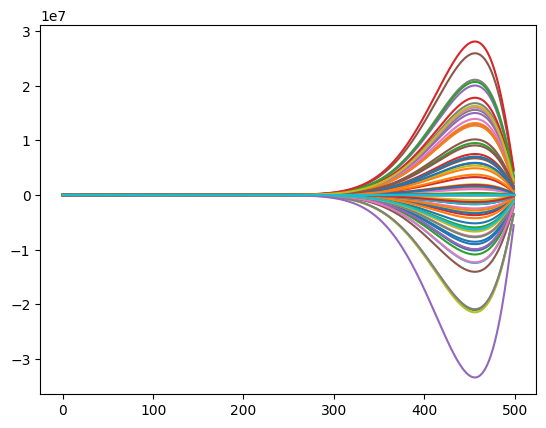

In [ ]:
_ = plt.plot(xs[::100,:,0].T)

/root/miniconda3/envs/probjax_new/lib/python3.12/site-packages/matplotlib/axes/_axes.py:6973: RuntimeWarning: All-NaN slice encountered
  xmin = min(xmin, np.nanmin(xi))
/root/miniconda3/envs/probjax_new/lib/python3.12/site-packages/matplotlib/axes/_axes.py:6974: RuntimeWarning: All-NaN slice encountered
  xmax = max(xmax, np.nanmax(xi))


ValueError: autodetected range of [nan, nan] is not finite

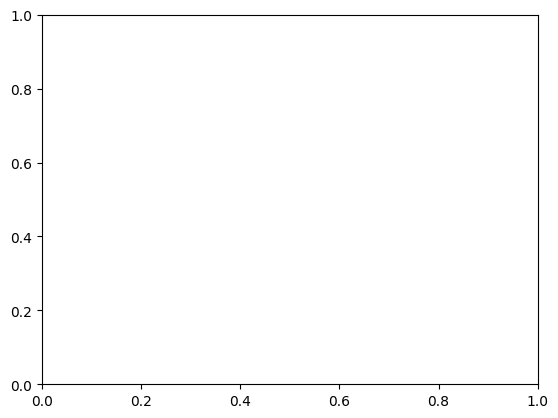

In [ ]:
_ = plt.hist(xs[:,-1].flatten(), bins=100, density=True)
_ = plt.plot(jnp.linspace(-3,3,100), jnp.exp(-jnp.linspace(-3,3,100)**2/2)/jnp.sqrt(2*jnp.pi))